# Banking Customer Data Analysis

## Project Overview

This project analyzes banking customer data to identify patterns in customer demographics, income, loans, deposits, account usage, and risk-related attributes.

The analysis uses Python for data cleaning, exploratory data analysis, statistical summaries, and visualization. The findings are intended to support business-oriented understanding of customer segments and banking behavior.

## Business Questions

- How are customers distributed across income bands?
- Which customer segments contribute the highest loan and deposit amounts?
- Is customer income associated with loan and deposit values?
- Which nationalities and customer segments contribute the most to banking activity?
- How does risk weighting vary across customer segments?
- Which account types contribute most to overall deposits?
- What relationships exist between loans, deposits, income, and account balances?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Load dataset
df = pd.read_csv('/content/Banking.csv')
df.head()


,Client ID,Name,Age,Location ID,Joined Bank,Banking Contact,Nationality,Occupation,Fee Structure,Loyalty Classification,...,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
0,IND81288,Raymond Mills,24,34324,06-05-2019,Anthony Torres,American,Safety Technician IV,High,Jade,...,1485828.64,603617.88,607332.46,12249.96,1134475.30,1,2,1,1,1
1,IND65833,Julia Spencer,23,42205,10-12-2001,Jonathan Hawkins,African,Software Consultant,High,Jade,...,641482.79,229521.37,344635.16,61162.31,2000526.10,1,3,2,1,2
2,IND47499,Stephen Murray,27,7314,25-01-2010,Anthony Berry,European,Help Desk Operator,High,Gold,...,1033401.59,652674.69,203054.35,79071.78,548137.58,1,3,3,2,3
3,IND72498,Virginia Garza,40,34594,28-03-2019,Steve Diaz,American,Geologist II,Mid,Silver,...,1048157.49,1048157.49,234685.02,57513.65,1148402.29,0,4,4,1,4
4,IND60181,Melissa Sanders,46,41269,20-07-2012,Shawn Long,American,Assistant Professor,Mid,Platinum,...,487782.53,446644.25,128351.45,30012.14,1674412.12,0,3,1,2,5


In [3]:
df.shape


(3000, 25)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Client ID                 3000 non-null   object 
 1   Name                      3000 non-null   object 
 2   Age                       3000 non-null   int64  
 3   Location ID               3000 non-null   int64  
 4   Joined Bank               3000 non-null   object 
 5   Banking Contact           3000 non-null   object 
 6   Nationality               3000 non-null   object 
 7   Occupation                3000 non-null   object 
 8   Fee Structure             3000 non-null   object 
 9   Loyalty Classification    3000 non-null   object 
 10  Estimated Income          3000 non-null   float64
 11  Superannuation Savings    3000 non-null   float64
 12  Amount of Credit Cards    3000 non-null   int64  
 13  Credit Card Balance       3000 non-null   float64
 14  Bank Loa

In [5]:
# Generate descriptive statistics for the dataframe
df.describe()

,Age,Location ID,Estimated Income,Superannuation Savings,Amount of Credit Cards,Credit Card Balance,Bank Loans,Bank Deposits,Checking Accounts,Saving Accounts,Foreign Currency Account,Business Lending,Properties Owned,Risk Weighting,BRId,GenderId,IAId
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3.000000e+03,3.000000e+03,3.000000e+03,3.000000e+03,3000.000000,3.000000e+03,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,51.039667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,6.715602e+05,3.210929e+05,2.329084e+05,29883.529993,8.667598e+05,1.518667,2.249333,2.559333,1.504000,10.425333
std,19.854760,12462.273017,111935.808209,16259.950770,0.676387,2497.094709,4.575570e+05,6.457169e+05,2.820796e+05,2.300078e+05,23109.924010,6.412303e+05,1.102145,1.131191,1.007713,0.500067,5.988242
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,45.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,2.044004e+05,1.199475e+05,7.479440e+04,11916.542500,3.748251e+05,1.000000,1.000000,2.000000,1.000000,5.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,4.633165e+05,2.428157e+05,1.640866e+05,24341.190000,7.113147e+05,2.000000,2.000000,3.000000,2.000000,10.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,9.427546e+05,4.348749e+05,3.155750e+05,41966.392500,1.185110e+06,2.000000,3.000000,3.000000,2.000000,15.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,3.890598e+06,1.969923e+06,1.724118e+06,124704.870000,3.825962e+06,3.000000,5.000000,4.000000,2.000000,22.000000


## 1. Data Quality Check

Before performing analysis, the dataset is checked for missing values, duplicate records, incorrect data types, and potential inconsistencies.

In [6]:
# Dataset dimensions
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Missing values
missing_values = df.isnull().sum().sort_values(ascending=False)

print("Missing values:")
display(missing_values[missing_values > 0])

# Duplicate records
print("Duplicate rows:", df.duplicated().sum())

# Unique clients
print("Unique clients:", df['Client ID'].nunique())

# Data types
display(df.dtypes)

Rows: 3000
Columns: 25
Missing values:


,0


Duplicate rows: 0
Unique clients: 2940


,0
Client ID,object
Name,object
Age,int64
Location ID,int64
Joined Bank,object
Banking Contact,object
Nationality,object
Occupation,object
Fee Structure,object
Loyalty Classification,object


In [7]:
df['Joined Bank'] = pd.to_datetime(
    df['Joined Bank'],
    format='%d-%m-%Y'
)

df['Joining Year'] = df['Joined Bank'].dt.year
df['Joining Month'] = df['Joined Bank'].dt.month

In [8]:
df[['Joined Bank', 'Joining Year', 'Joining Month']].head()

,Joined Bank,Joining Year,Joining Month
0,2019-05-06,2019,5
1,2001-12-10,2001,12
2,2010-01-25,2010,1
3,2019-03-28,2019,3
4,2012-07-20,2012,7


In [9]:
bins = [0, 100000, 300000, float('inf')]
labels = ['Low', 'Mid', 'High']

df['Income Band'] = pd.cut(df['Estimated Income'], bins=bins, labels=labels, right=False)

<Axes: xlabel='Income Band'>

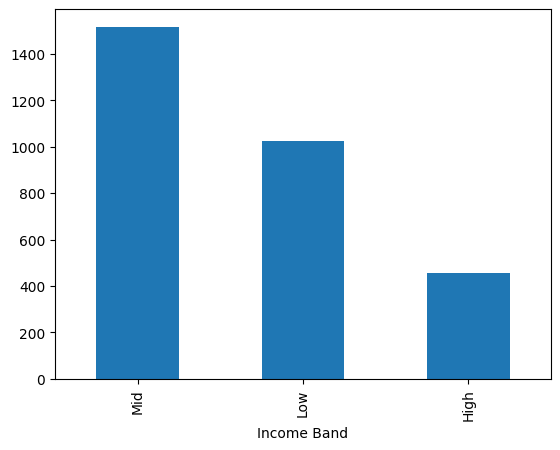

In [10]:
df['Income Band'].value_counts().plot(kind='bar')

In [11]:
income_summary = df.groupby('Income Band', observed=True).agg(
    Customers=('Client ID', 'nunique'),
    Avg_Income=('Estimated Income', 'mean'),
    Total_Loans=('Bank Loans', 'sum'),
    Total_Deposits=('Bank Deposits', 'sum'),
    Avg_Risk=('Risk Weighting', 'mean')
).reset_index()

income_summary

,Income Band,Customers,Avg_Income,Total_Loans,Total_Deposits,Avg_Risk
0,Low,1021,64689.030399,4.481933e+08,4.993511e+08,1.504382
1,Mid,1495,182132.356025,9.424915e+08,1.091331e+09,2.355307
2,High,455,375405.009825,3.834736e+08,4.239990e+08,3.574561


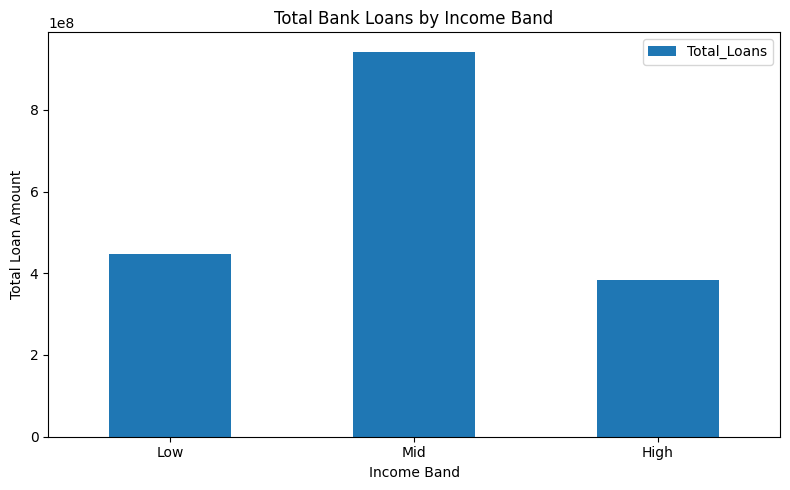

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))

income_summary.plot(
    x='Income Band',
    y='Total_Loans',
    kind='bar',
    ax=ax
)

ax.set_title('Total Bank Loans by Income Band')
ax.set_xlabel('Income Band')
ax.set_ylabel('Total Loan Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 1. Data Preparation & Derived Metrics

Additional metrics are created to support business-oriented banking analysis.


In [13]:
# Total loan exposure combines the major lending components in the dataset.
df['Total Loan Exposure'] = (
    df['Bank Loans']
    + df['Business Lending']
    + df['Credit Card Balance']
)

# Loan-to-deposit ratio for customers with positive deposits.
df['Loan_to_Deposit_Ratio'] = np.where(
    df['Bank Deposits'] > 0,
    df['Total Loan Exposure'] / df['Bank Deposits'],
    np.nan
)

df[['Total Loan Exposure', 'Loan_to_Deposit_Ratio']].describe()


,Total Loan Exposure,Loan_to_Deposit_Ratio
count,3.000000e+03,2966.000000
mean,1.461322e+06,4.594137
std,9.312684e+05,6.282811
min,5.595170e+04,0.094065
25%,7.704137e+05,1.480316
50%,1.225764e+06,2.521182
75%,1.958647e+06,4.790755
max,6.078679e+06,60.504598


## 2. Income and Loan Analysis


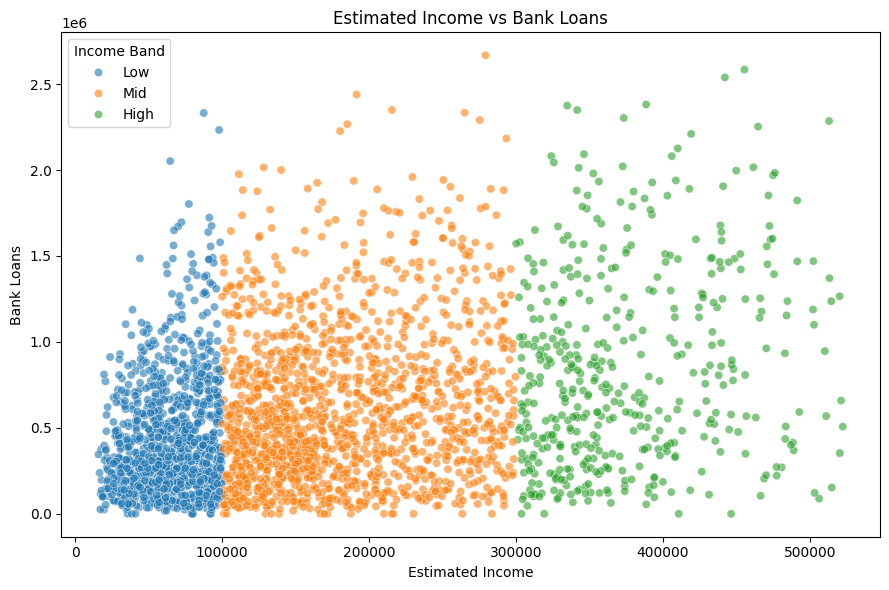

Correlation between income and bank loans: 0.33


In [14]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Estimated Income',
    y='Bank Loans',
    hue='Income Band',
    alpha=0.6
)
plt.title('Estimated Income vs Bank Loans')
plt.xlabel('Estimated Income')
plt.ylabel('Bank Loans')
plt.tight_layout()
plt.show()

income_loan_corr = df['Estimated Income'].corr(df['Bank Loans'])
print(f'Correlation between income and bank loans: {income_loan_corr:.2f}')


### Income and Deposit Analysis


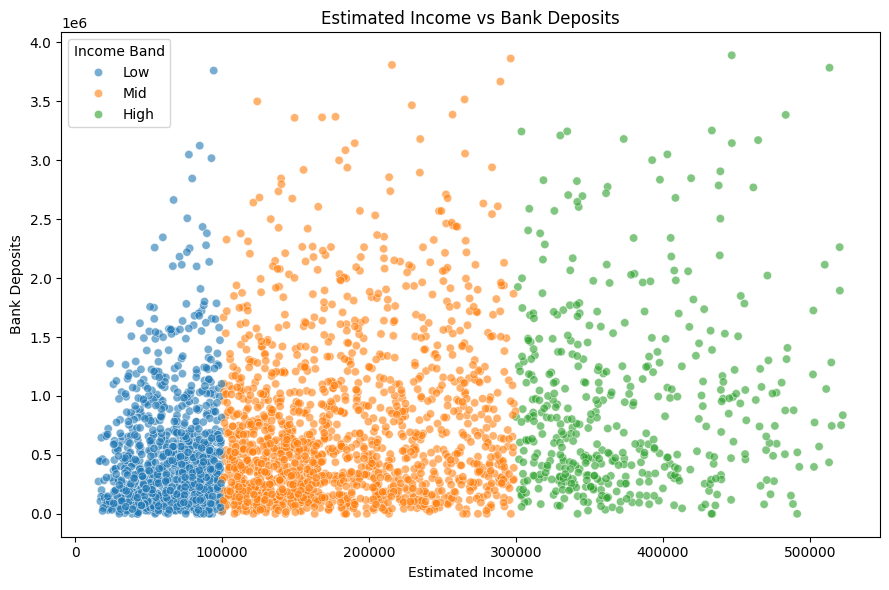

Correlation between income and bank deposits: 0.26


In [15]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Estimated Income',
    y='Bank Deposits',
    hue='Income Band',
    alpha=0.6
)
plt.title('Estimated Income vs Bank Deposits')
plt.xlabel('Estimated Income')
plt.ylabel('Bank Deposits')
plt.tight_layout()
plt.show()

income_deposit_corr = df['Estimated Income'].corr(df['Bank Deposits'])
print(f'Correlation between income and bank deposits: {income_deposit_corr:.2f}')


### Financial Behavior by Income Band


In [16]:
income_summary = df.groupby('Income Band', observed=True).agg(
    Customers=('Client ID', 'nunique'),
    Avg_Income=('Estimated Income', 'mean'),
    Total_Loans=('Bank Loans', 'sum'),
    Avg_Loan=('Bank Loans', 'mean'),
    Total_Deposits=('Bank Deposits', 'sum'),
    Avg_Deposit=('Bank Deposits', 'mean'),
    Avg_Risk=('Risk Weighting', 'mean')
).reset_index()

display(income_summary)


,Income Band,Customers,Avg_Income,Total_Loans,Avg_Loan,Total_Deposits,Avg_Deposit,Avg_Risk
0,Low,1021,64689.030399,4.481933e+08,436410.192648,4.993511e+08,486223.059533,1.504382
1,Mid,1495,182132.356025,9.424915e+08,621286.453296,1.091331e+09,719400.462544,2.355307
2,High,455,375405.009825,3.834736e+08,840950.984561,4.239990e+08,929822.363925,3.574561


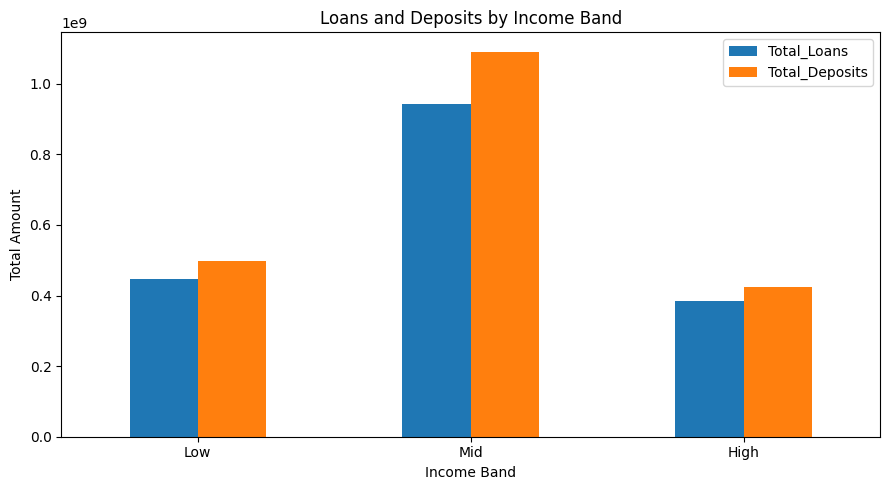

In [17]:
income_summary.set_index('Income Band')[['Total_Loans', 'Total_Deposits']].plot(
    kind='bar',
    figsize=(9, 5)
)
plt.title('Loans and Deposits by Income Band')
plt.xlabel('Income Band')
plt.ylabel('Total Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 3. Loan Portfolio Analysis


,Total Amount
Business Lending,2.600279e+09
Bank Loans,1.774158e+09
Credit Card Balance,9.528621e+06


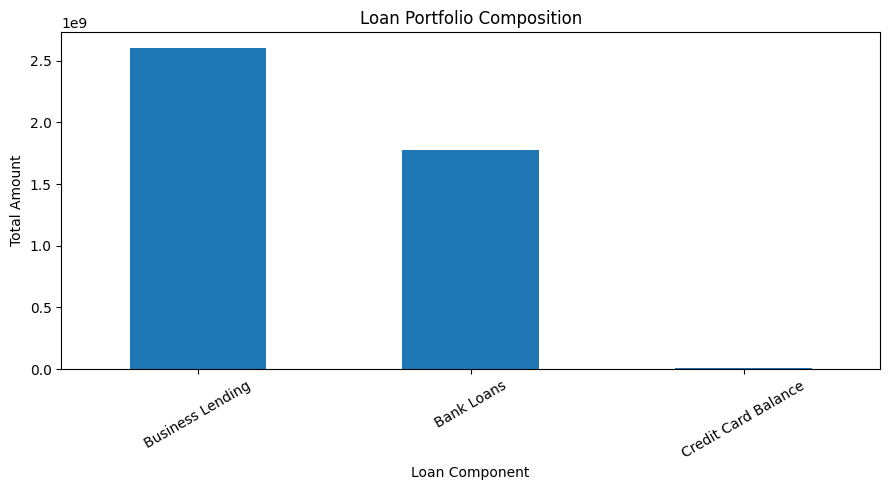

In [18]:
loan_components = df[
    ['Bank Loans', 'Business Lending', 'Credit Card Balance']
].sum().sort_values(ascending=False)

display(loan_components.to_frame('Total Amount'))

loan_components.plot(kind='bar', figsize=(9, 5))
plt.title('Loan Portfolio Composition')
plt.xlabel('Loan Component')
plt.ylabel('Total Amount')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Loans by Nationality


In [19]:
nationality_loans = (
    df.groupby('Nationality')
      .agg(
          Customers=('Client ID', 'nunique'),
          Total_Loans=('Bank Loans', 'sum'),
          Avg_Loan=('Bank Loans', 'mean'),
          Total_Deposits=('Bank Deposits', 'sum')
      )
      .sort_values('Total_Loans', ascending=False)
)

nationality_loans['Loan_per_Customer'] = (
    nationality_loans['Total_Loans'] /
    nationality_loans['Customers']
)

display(nationality_loans)


,Customers,Total_Loans,Avg_Loan,Total_Deposits,Loan_per_Customer
Nationality,,,,,
European,1299,7.776157e+08,594053.258610,8.739655e+08,598626.416875
Asian,753,4.361874e+08,578497.850889,5.153119e+08,579266.108327
American,505,3.060279e+08,603605.282899,3.353003e+08,605995.798871
Australian,252,1.541581e+08,606921.474252,1.690381e+08,611738.311349
African,176,1.001694e+08,569144.536818,1.210648e+08,569144.536818


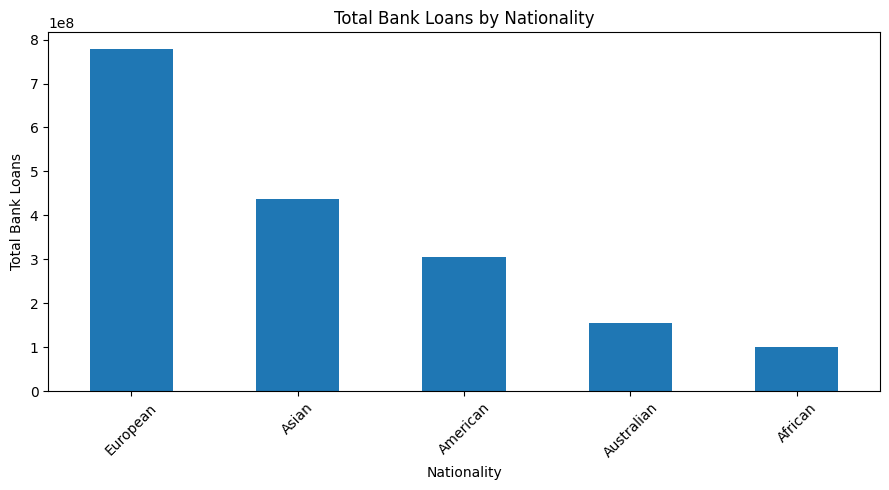

In [20]:
nationality_loans['Total_Loans'].plot(
    kind='bar',
    figsize=(9, 5)
)
plt.title('Total Bank Loans by Nationality')
plt.xlabel('Nationality')
plt.ylabel('Total Bank Loans')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Top Occupations by Loan Exposure


,Customers,Total_Loans,Avg_Loan
Occupation,,,
Account Coordinator,24,17361475.90,723394.829167
Database Administrator III,23,17164556.98,746285.086087
Office Assistant III,19,16410477.91,863709.363684
Automation Specialist IV,22,16373745.15,744261.143182
Structural Analysis Engineer,28,16077177.39,574184.906786
Software Consultant,18,15334011.94,851889.552222
General Manager,16,15174316.68,948394.792500
Accountant II,18,14981582.11,832310.117222
Actuary,17,14568475.52,856969.148235


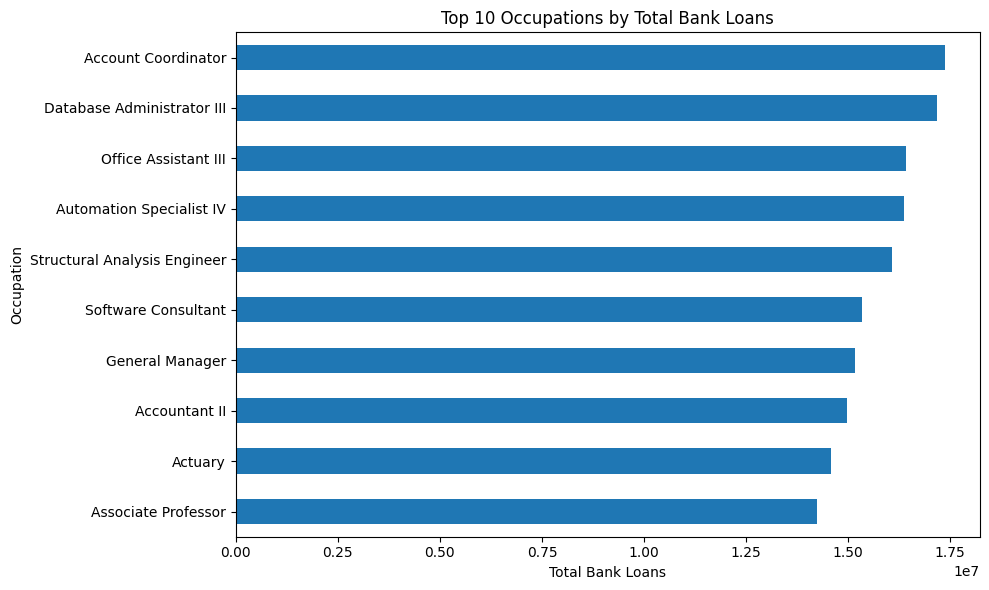

In [21]:
top_occupations = (
    df.groupby('Occupation')
      .agg(
          Customers=('Client ID', 'nunique'),
          Total_Loans=('Bank Loans', 'sum'),
          Avg_Loan=('Bank Loans', 'mean')
      )
      .sort_values('Total_Loans', ascending=False)
      .head(10)
)

display(top_occupations)

top_occupations['Total_Loans'].sort_values().plot(
    kind='barh',
    figsize=(10, 6)
)
plt.title('Top 10 Occupations by Total Bank Loans')
plt.xlabel('Total Bank Loans')
plt.ylabel('Occupation')
plt.tight_layout()
plt.show()


## 4. Deposit & Account Analysis


,Total Amount
Bank Deposits,2.014681e+09
Checking Accounts,9.632788e+08
Saving Accounts,6.987251e+08
Foreign Currency Account,8.965059e+07


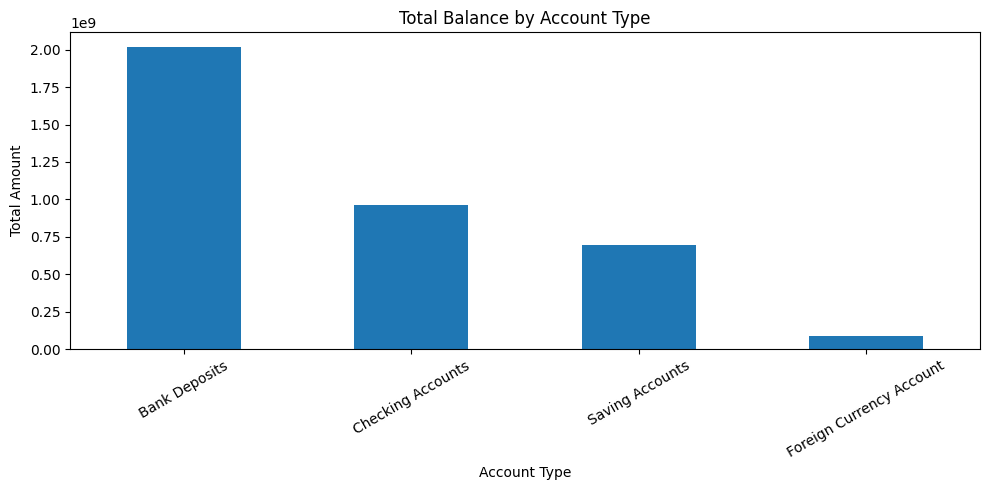

In [22]:
account_columns = [
    'Bank Deposits',
    'Checking Accounts',
    'Saving Accounts',
    'Foreign Currency Account'
]

account_totals = df[account_columns].sum().sort_values(ascending=False)
display(account_totals.to_frame('Total Amount'))

account_totals.plot(kind='bar', figsize=(10, 5))
plt.title('Total Balance by Account Type')
plt.xlabel('Account Type')
plt.ylabel('Total Amount')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Deposit Behavior by Loyalty Classification


,Customers,Avg_Income,Avg_Loan,Avg_Deposit,Avg_Credit_Balance
Loyalty Classification,,,,,
Jade,1319,172418.944673,605675.797543,696576.840571,3213.840443
Gold,583,167876.148718,574376.369692,664384.579521,3281.448957
Silver,763,175105.559244,590547.950404,658361.291382,3123.926780
Platinum,317,163760.178202,564806.074763,611699.424164,2950.472303


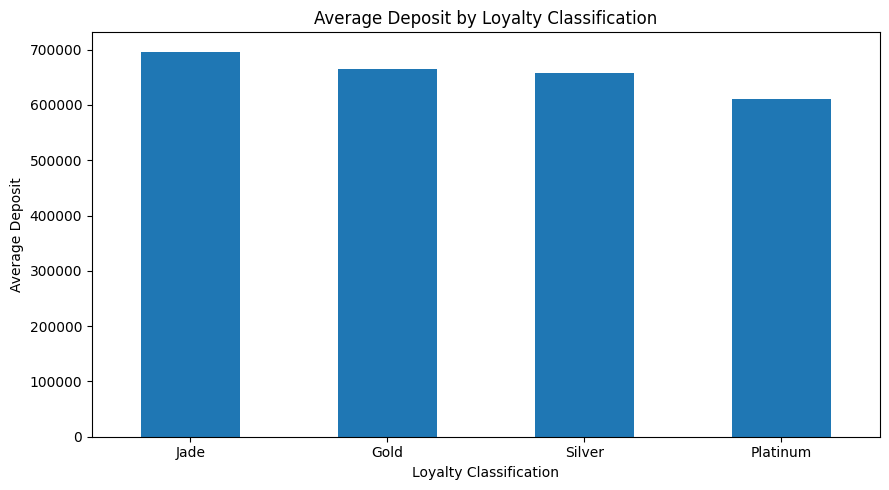

In [23]:
loyalty_summary = df.groupby('Loyalty Classification').agg(
    Customers=('Client ID', 'nunique'),
    Avg_Income=('Estimated Income', 'mean'),
    Avg_Loan=('Bank Loans', 'mean'),
    Avg_Deposit=('Bank Deposits', 'mean'),
    Avg_Credit_Balance=('Credit Card Balance', 'mean')
).sort_values('Avg_Deposit', ascending=False)

display(loyalty_summary)

loyalty_summary['Avg_Deposit'].plot(
    kind='bar',
    figsize=(9, 5)
)
plt.title('Average Deposit by Loyalty Classification')
plt.xlabel('Loyalty Classification')
plt.ylabel('Average Deposit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Risk Analysis


In [24]:
risk_summary = df.groupby('Risk Weighting').agg(
    Customers=('Client ID', 'nunique'),
    Avg_Income=('Estimated Income', 'mean'),
    Total_Loans=('Bank Loans', 'sum'),
    Avg_Loan=('Bank Loans', 'mean'),
    Total_Deposits=('Bank Deposits', 'sum'),
    Avg_Deposit=('Bank Deposits', 'mean'),
    Avg_Loan_to_Deposit=('Loan_to_Deposit_Ratio', 'mean')
).reset_index()

display(risk_summary)


,Risk Weighting,Customers,Avg_Income,Total_Loans,Avg_Loan,Total_Deposits,Avg_Deposit,Avg_Loan_to_Deposit
0,1,832,77539.978780,2.793846e+08,334192.148553,3.162141e+08,3.782465e+05,4.581587
1,2,1211,159256.784984,7.036090e+08,575784.755401,7.995209e+08,6.542724e+05,4.658424
2,3,460,246057.653957,3.618521e+08,786634.906804,4.046151e+08,8.795981e+05,4.585928
3,4,322,284741.650186,2.732781e+08,848689.886770,3.124214e+08,9.702528e+05,4.497025
4,5,160,310040.981875,1.560347e+08,975216.615625,1.819091e+08,1.136932e+06,4.387998


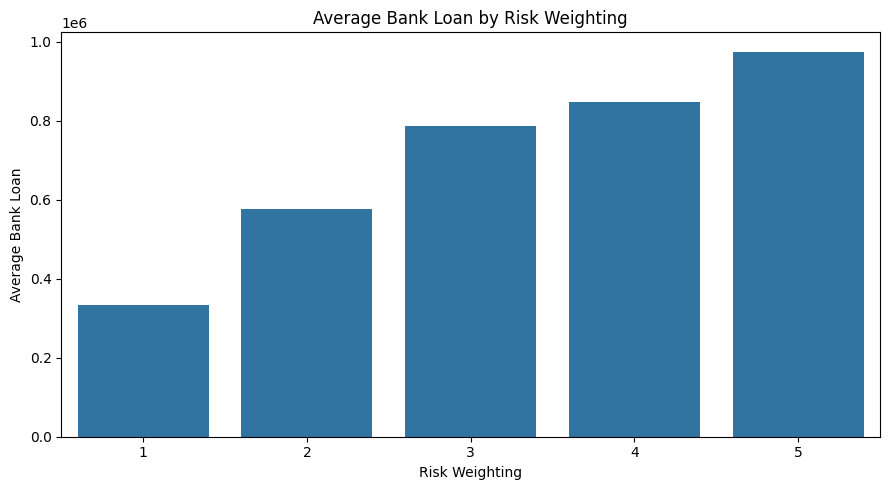

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=risk_summary, x='Risk Weighting', y='Avg_Loan', ax=ax)
ax.set_title('Average Bank Loan by Risk Weighting')
ax.set_xlabel('Risk Weighting')
ax.set_ylabel('Average Bank Loan')
plt.tight_layout()
plt.show()


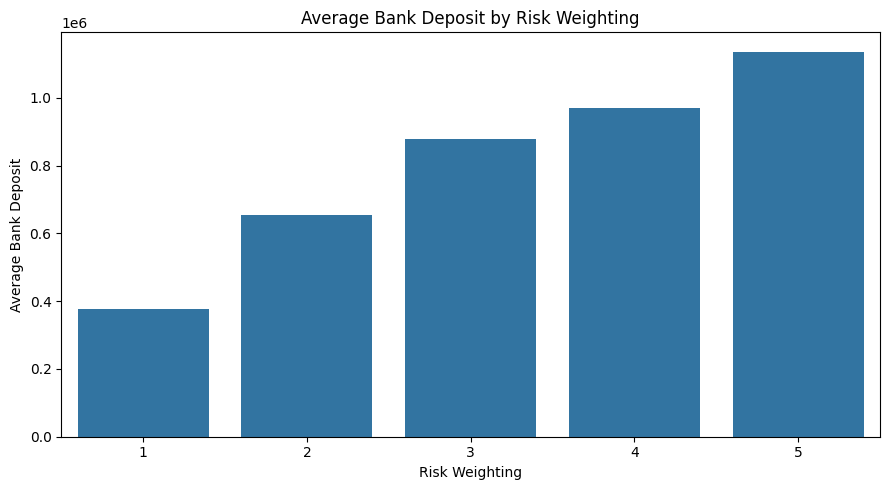

In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=risk_summary, x='Risk Weighting', y='Avg_Deposit', ax=ax)
ax.set_title('Average Bank Deposit by Risk Weighting')
ax.set_xlabel('Risk Weighting')
ax.set_ylabel('Average Bank Deposit')
plt.tight_layout()
plt.show()


## 6. Loan-to-Deposit Analysis


,Average Loan-to-Deposit Ratio
Income Band,
Low,4.724996
Mid,4.576309
High,4.360067


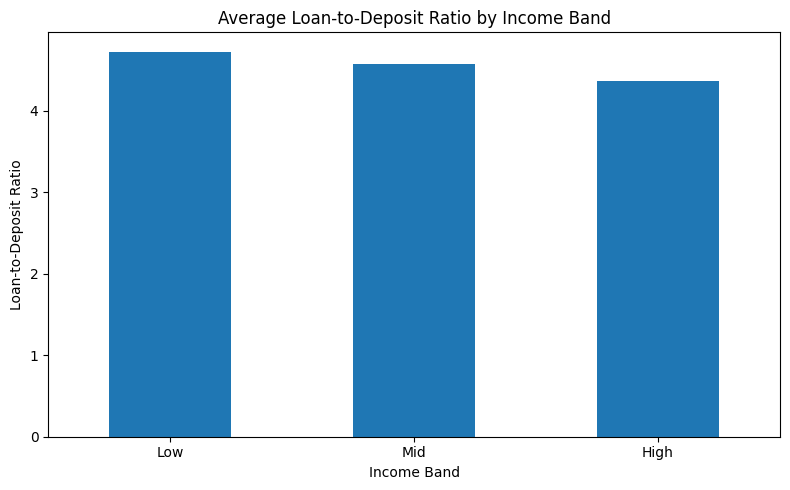

In [27]:
ldr_by_income = df.groupby(
    'Income Band',
    observed=True
)['Loan_to_Deposit_Ratio'].mean()

display(ldr_by_income.to_frame('Average Loan-to-Deposit Ratio'))

ldr_by_income.plot(kind='bar', figsize=(8, 5))
plt.title('Average Loan-to-Deposit Ratio by Income Band')
plt.xlabel('Income Band')
plt.ylabel('Loan-to-Deposit Ratio')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 2. Customer Profile Analysis

Instead of plotting every categorical field, this section focuses on business-relevant customer attributes: nationality, loyalty classification, risk weighting, number of credit cards, and properties owned.


In [28]:
categorical_cols = [
    'Nationality',
    'Loyalty Classification',
    'Risk Weighting',
    'Amount of Credit Cards',
    'Properties Owned',
    'Income Band'
]

for col in categorical_cols:
    print(f"\n{col}")
    display(df[col].value_counts().to_frame('Customers'))



Nationality


,Customers
Nationality,
European,1309
Asian,754
American,507
Australian,254
African,176



Loyalty Classification


,Customers
Loyalty Classification,
Jade,1331
Silver,767
Gold,585
Platinum,317



Risk Weighting


...

,Customers
Amount of Credit Cards,
1,1922
2,765
3,313



Properties Owned


,Customers
Properties Owned,
2,777
1,776
3,742
0,705



Income Band


,Customers
Income Band,
Mid,1517
Low,1027
High,456


### Customer Segmentation by Loyalty Classification


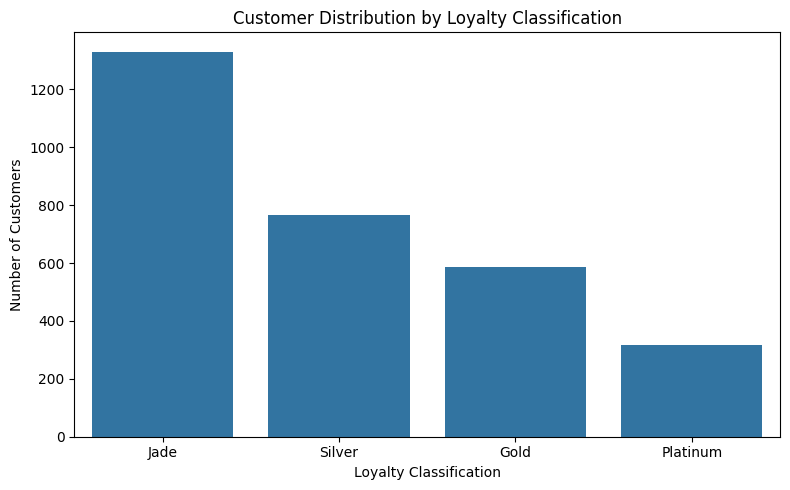

In [29]:
loyalty_counts = (
    df['Loyalty Classification']
      .value_counts()
      .rename_axis('Loyalty Classification')
      .reset_index(name='Customers')
)

plt.figure(figsize=(8, 5))
sns.barplot(data=loyalty_counts, x='Loyalty Classification', y='Customers')
plt.title('Customer Distribution by Loyalty Classification')
plt.xlabel('Loyalty Classification')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()


## 3. Numerical Analysis

The numerical variables are reviewed using summary statistics and individual distributions to understand scale, spread, and potential outliers.


,count,mean,std,min,25%,50%,75%,max
Estimated Income,3000.0,171305.034263,111935.808209,15919.48,82906.5950,142313.480,2.422903e+05,522330.26
Superannuation Savings,3000.0,25531.599673,16259.950770,1482.03,12513.7750,22357.355,3.546474e+04,75963.90
Credit Card Balance,3000.0,3176.206943,2497.094709,1.17,1236.6300,2560.805,4.522632e+03,13991.99
Bank Loans,3000.0,591386.155487,457557.036334,0.00,239628.1375,479793.400,8.258130e+05,2667556.66
Bank Deposits,3000.0,671560.193923,645716.856875,0.00,204400.3750,463316.460,9.427546e+05,3890598.08
Checking Accounts,3000.0,321092.949127,282079.553893,0.00,119947.5300,242815.655,4.348749e+05,1969923.08
Saving Accounts,3000.0,232908.353483,230007.777498,0.00,74794.4050,164086.555,3.155750e+05,1724118.36
Foreign Currency Account,3000.0,29883.529993,23109.924010,45.00,11916.5425,24341.190,4.196639e+04,124704.87
Business Lending,3000.0,866759.808407,641230.321823,0.00,374825.1375,711314.660,1.185110e+06,3825961.94


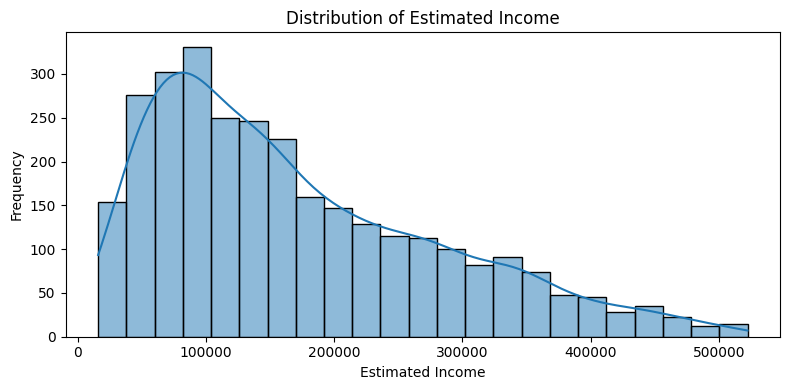

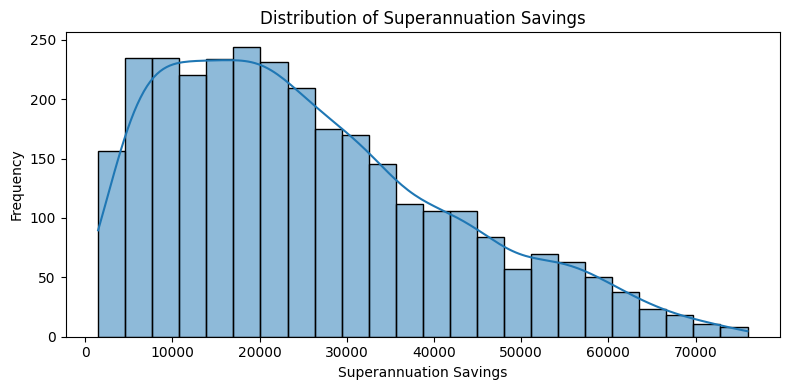

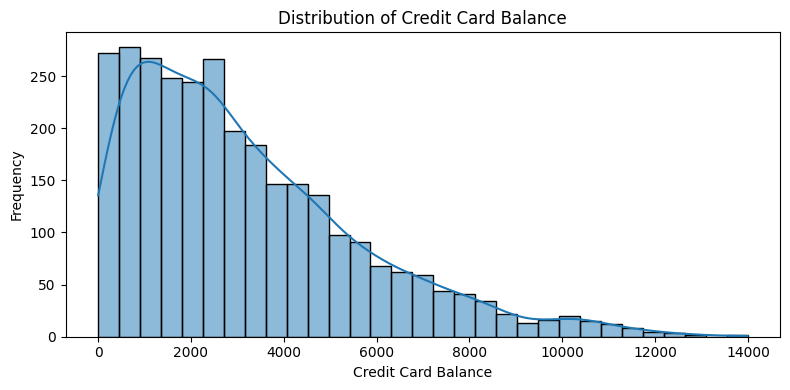

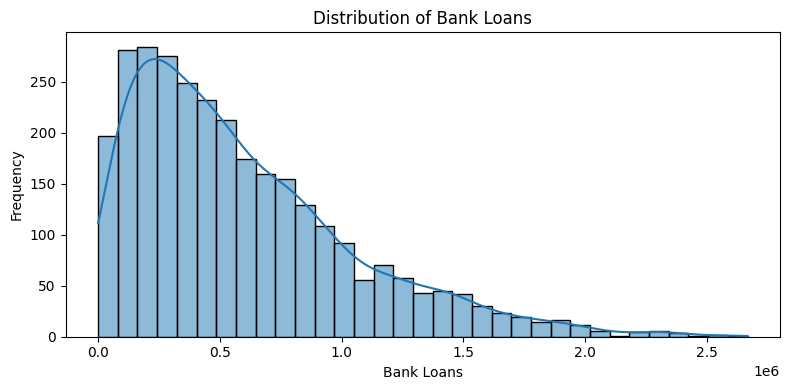

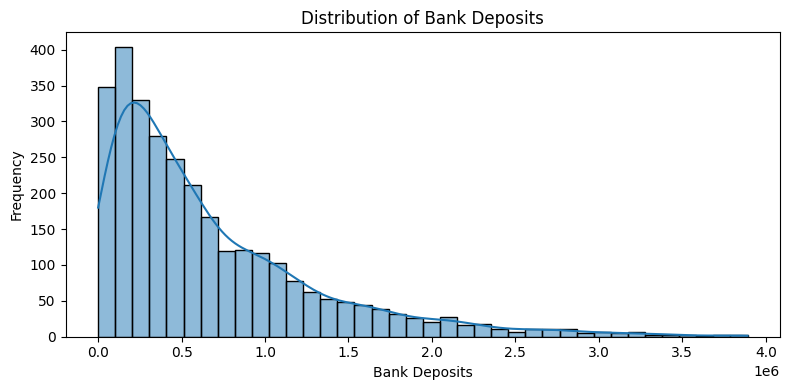

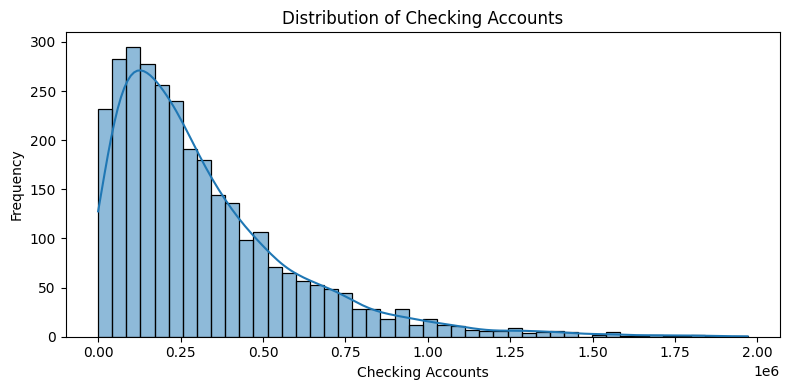

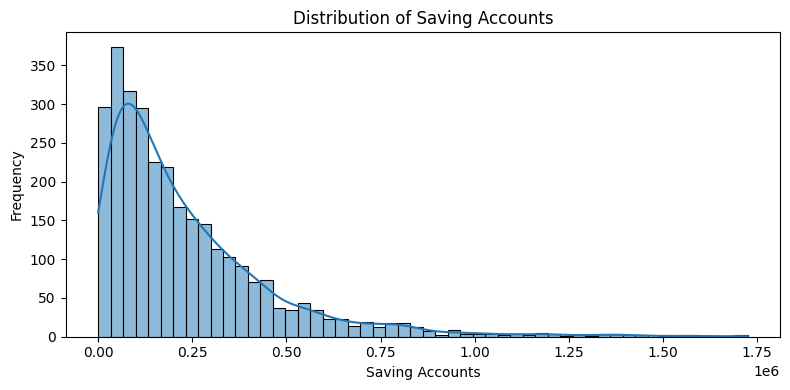

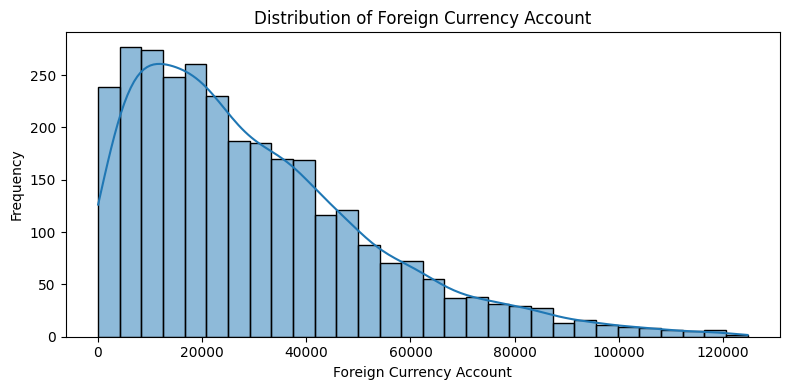

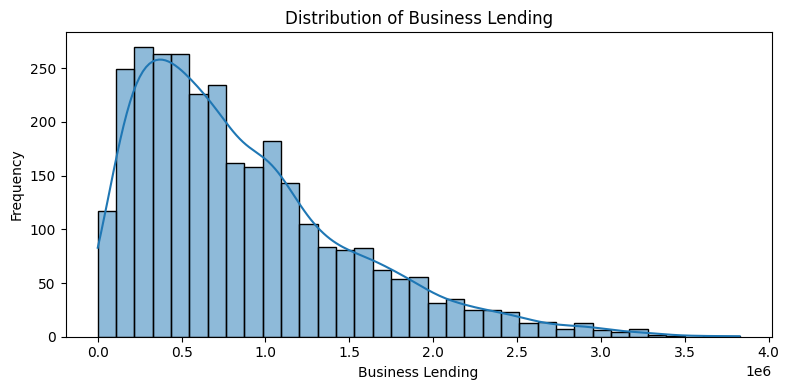

In [30]:
numerical_cols = [
    'Estimated Income',
    'Superannuation Savings',
    'Credit Card Balance',
    'Bank Loans',
    'Bank Deposits',
    'Checking Accounts',
    'Saving Accounts',
    'Foreign Currency Account',
    'Business Lending'
]

display(df[numerical_cols].describe().T)

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


## 4. Correlation Analysis

Correlation is used to identify linear relationships among major financial variables. Correlation does not imply causation.


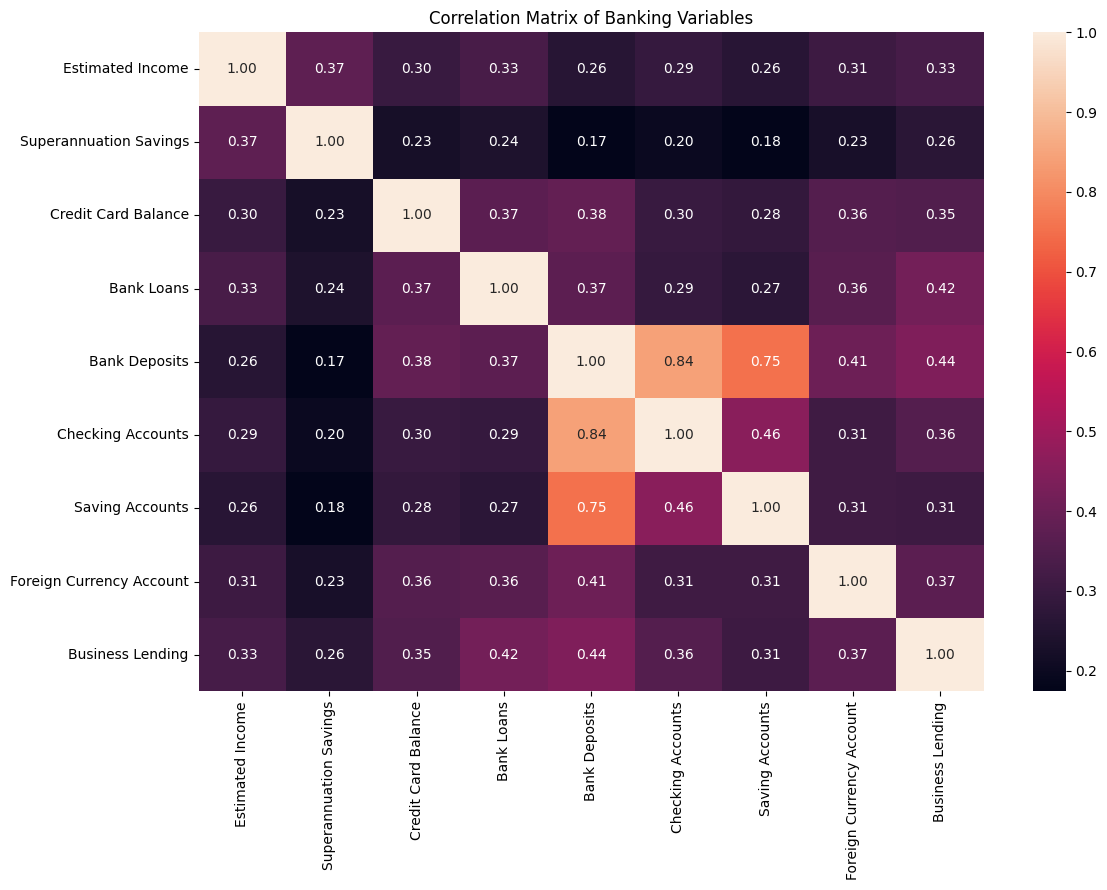

In [31]:
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f')
plt.title('Correlation Matrix of Banking Variables')
plt.tight_layout()
plt.show()


In [32]:
corr_pairs = (
    correlation_matrix
    .where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ['Variable 1', 'Variable 2', 'Correlation']
corr_pairs['Absolute Correlation'] = corr_pairs['Correlation'].abs()

top_correlations = corr_pairs.sort_values(
    'Absolute Correlation',
    ascending=False
).head(10)

display(top_correlations)


,Variable 1,Variable 2,Correlation,Absolute Correlation
26,Bank Deposits,Checking Accounts,0.844278,0.844278
27,Bank Deposits,Saving Accounts,0.754744,0.754744
30,Checking Accounts,Saving Accounts,0.459509,0.459509
29,Bank Deposits,Business Lending,0.441298,0.441298
25,Bank Loans,Business Lending,0.417095,0.417095
28,Bank Deposits,Foreign Currency Account,0.406347,0.406347
16,Credit Card Balance,Bank Deposits,0.383877,0.383877
0,Estimated Income,Superannuation Savings,0.374802,0.374802
21,Bank Loans,Bank Deposits,0.373155,0.373155
35,Foreign Currency Account,Business Lending,0.369749,0.369749


## 2. Income and Loan Analysis

This section examines whether customer income is associated with borrowing activity.

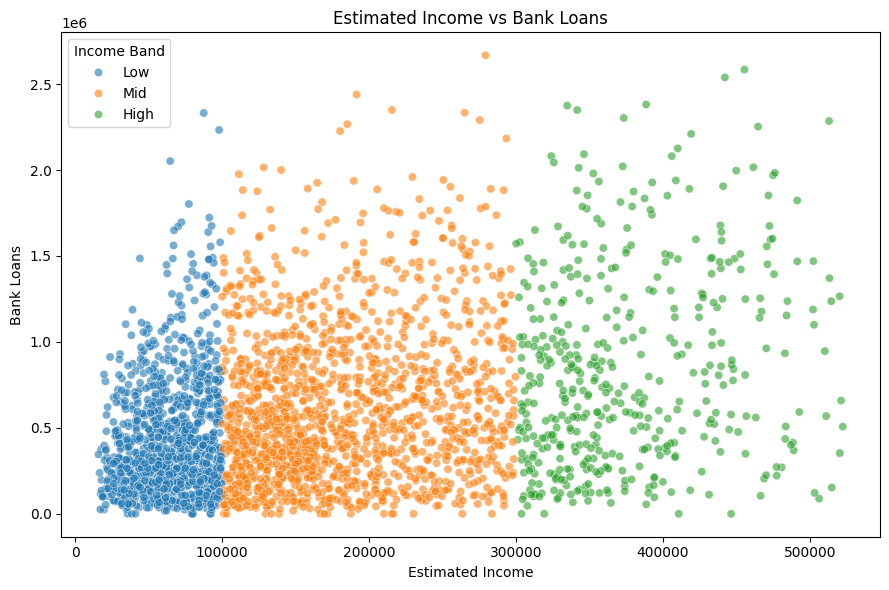

In [33]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Estimated Income',
    y='Bank Loans',
    hue='Income Band',
    alpha=0.6
)

plt.title('Estimated Income vs Bank Loans')
plt.xlabel('Estimated Income')
plt.ylabel('Bank Loans')
plt.tight_layout()
plt.show()

In [34]:
income_loan_corr = df['Estimated Income'].corr(df['Bank Loans'])

print(f"Correlation between income and bank loans: {income_loan_corr:.2f}")

Correlation between income and bank loans: 0.33


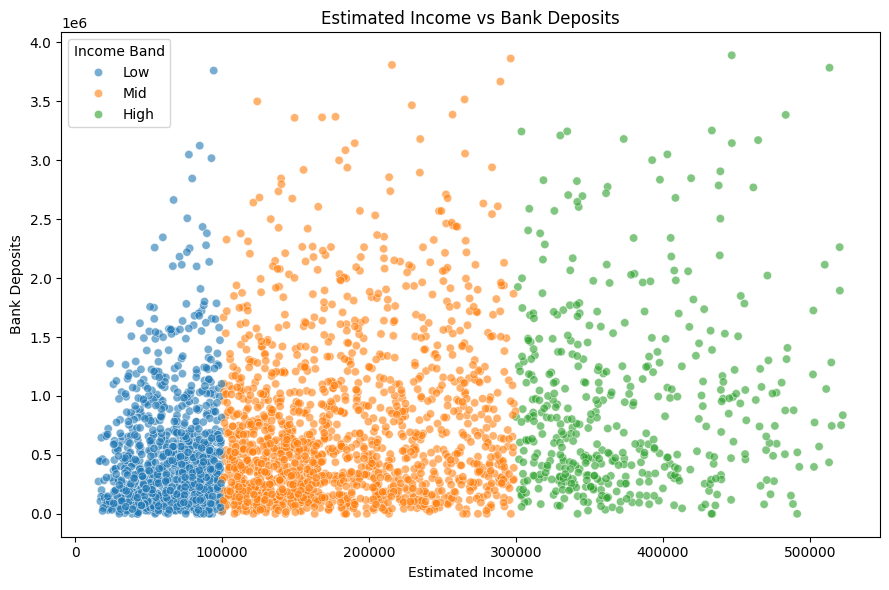

In [35]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x='Estimated Income',
    y='Bank Deposits',
    hue='Income Band',
    alpha=0.6
)

plt.title('Estimated Income vs Bank Deposits')
plt.xlabel('Estimated Income')
plt.ylabel('Bank Deposits')
plt.tight_layout()
plt.show()

In [36]:
income_deposit_corr = df['Estimated Income'].corr(
    df['Bank Deposits']
)

print(f"Correlation between income and deposits: {income_deposit_corr:.2f}")

Correlation between income and deposits: 0.26


In [37]:
nationality_loans = (
    df.groupby('Nationality')
      .agg(
          Customers=('Client ID', 'nunique'),
          Total_Loans=('Bank Loans', 'sum'),
          Avg_Loan=('Bank Loans', 'mean'),
          Total_Deposits=('Bank Deposits', 'sum')
      )
      .sort_values('Total_Loans', ascending=False)
)

nationality_loans

,Customers,Total_Loans,Avg_Loan,Total_Deposits
Nationality,,,,
European,1299,7.776157e+08,594053.258610,8.739655e+08
Asian,753,4.361874e+08,578497.850889,5.153119e+08
American,505,3.060279e+08,603605.282899,3.353003e+08
Australian,252,1.541581e+08,606921.474252,1.690381e+08
African,176,1.001694e+08,569144.536818,1.210648e+08


In [38]:
nationality_loans['Loan_per_Customer'] = (
    nationality_loans['Total_Loans'] /
    nationality_loans['Customers']
)

nationality_loans

,Customers,Total_Loans,Avg_Loan,Total_Deposits,Loan_per_Customer
Nationality,,,,,
European,1299,7.776157e+08,594053.258610,8.739655e+08,598626.416875
Asian,753,4.361874e+08,578497.850889,5.153119e+08,579266.108327
American,505,3.060279e+08,603605.282899,3.353003e+08,605995.798871
Australian,252,1.541581e+08,606921.474252,1.690381e+08,611738.311349
African,176,1.001694e+08,569144.536818,1.210648e+08,569144.536818


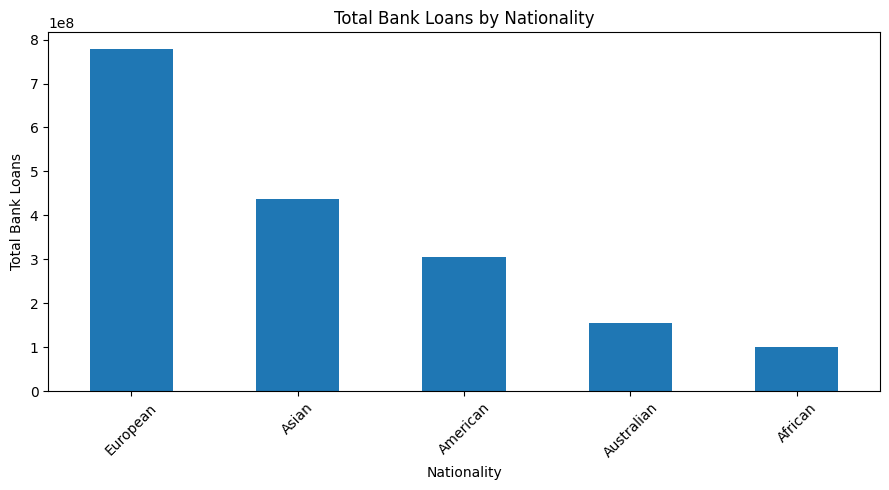

In [39]:
nationality_loans['Total_Loans'].plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Total Bank Loans by Nationality')
plt.xlabel('Nationality')
plt.ylabel('Total Bank Loans')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Risk Analysis

Risk weighting is analyzed to understand how loan and deposit behavior varies across risk categories.

In [40]:
risk_summary = df.groupby('Risk Weighting').agg(
    Customers=('Client ID', 'nunique'),
    Avg_Income=('Estimated Income', 'mean'),
    Total_Loans=('Bank Loans', 'sum'),
    Avg_Loan=('Bank Loans', 'mean'),
    Total_Deposits=('Bank Deposits', 'sum'),
    Avg_Deposit=('Bank Deposits', 'mean')
).reset_index()

risk_summary

,Risk Weighting,Customers,Avg_Income,Total_Loans,Avg_Loan,Total_Deposits,Avg_Deposit
0,1,832,77539.978780,2.793846e+08,334192.148553,3.162141e+08,3.782465e+05
1,2,1211,159256.784984,7.036090e+08,575784.755401,7.995209e+08,6.542724e+05
2,3,460,246057.653957,3.618521e+08,786634.906804,4.046151e+08,8.795981e+05
3,4,322,284741.650186,2.732781e+08,848689.886770,3.124214e+08,9.702528e+05
4,5,160,310040.981875,1.560347e+08,975216.615625,1.819091e+08,1.136932e+06


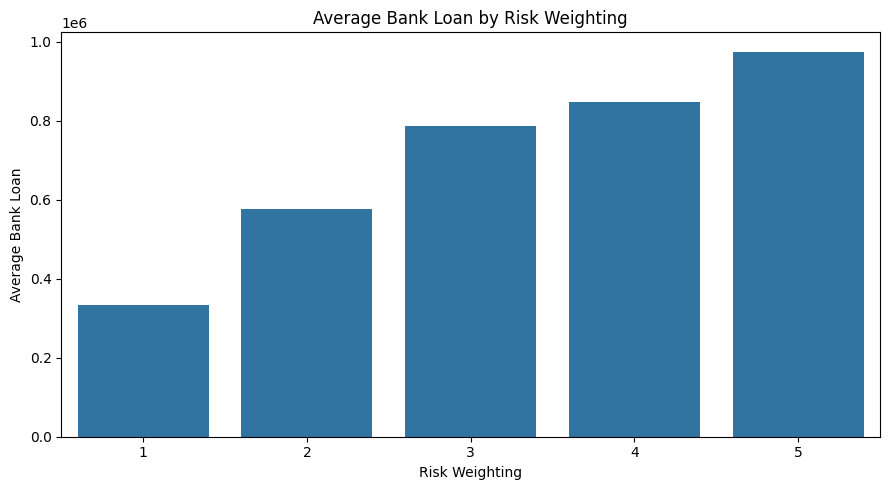

In [41]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=risk_summary,
    x='Risk Weighting',
    y='Avg_Loan'
)

plt.title('Average Bank Loan by Risk Weighting')
plt.xlabel('Risk Weighting')
plt.ylabel('Average Bank Loan')
plt.tight_layout()
plt.show()

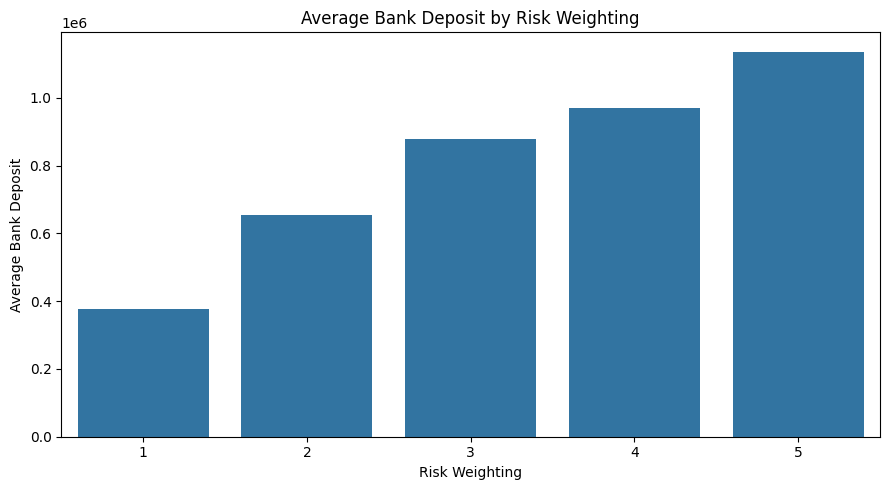

In [42]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=risk_summary,
    x='Risk Weighting',
    y='Avg_Deposit'
)

plt.title('Average Bank Deposit by Risk Weighting')
plt.xlabel('Risk Weighting')
plt.ylabel('Average Bank Deposit')
plt.tight_layout()
plt.show()

In [43]:
account_columns = [
    'Bank Deposits',
    'Checking Accounts',
    'Saving Accounts',
    'Foreign Currency Account'
]

account_totals = df[account_columns].sum().sort_values(
    ascending=False
)

account_totals

,0
Bank Deposits,2.014681e+09
Checking Accounts,9.632788e+08
Saving Accounts,6.987251e+08
Foreign Currency Account,8.965059e+07


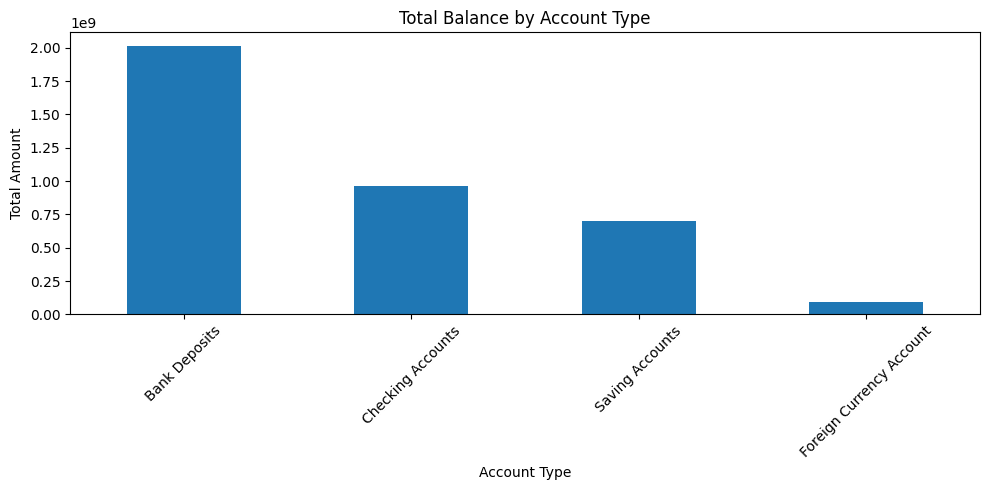

In [44]:
account_totals.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Total Balance by Account Type')
plt.xlabel('Account Type')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
df['Total Loan Exposure'] = (
    df['Bank Loans']
    + df['Business Lending']
    + df['Credit Card Balance']
)

In [46]:
loan_components = df[
    ['Bank Loans', 'Business Lending', 'Credit Card Balance']
].sum().sort_values(ascending=False)

loan_components

,0
Business Lending,2.600279e+09
Bank Loans,1.774158e+09
Credit Card Balance,9.528621e+06


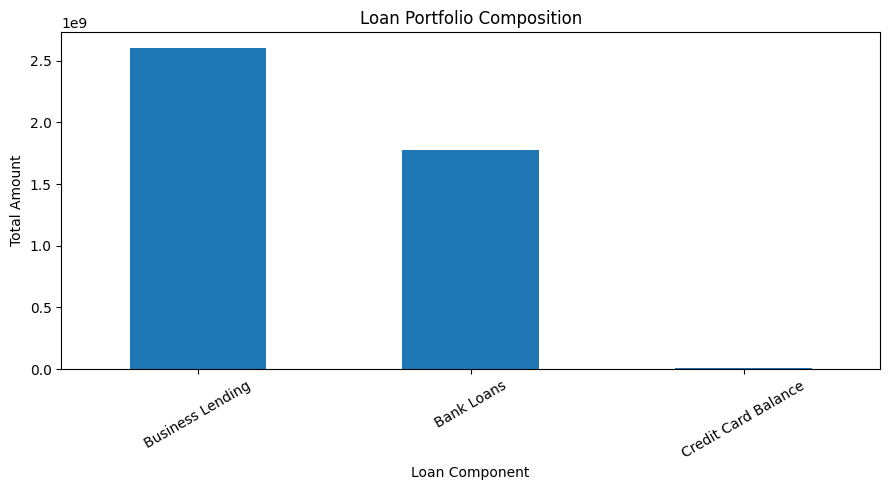

In [47]:
loan_components.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Loan Portfolio Composition')
plt.xlabel('Loan Component')
plt.ylabel('Total Amount')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [48]:
loyalty_summary = df.groupby('Loyalty Classification').agg(
    Customers=('Client ID', 'nunique'),
    Avg_Income=('Estimated Income', 'mean'),
    Avg_Loan=('Bank Loans', 'mean'),
    Avg_Deposit=('Bank Deposits', 'mean'),
    Avg_Credit_Balance=('Credit Card Balance', 'mean')
).sort_values('Avg_Deposit', ascending=False)

loyalty_summary

,Customers,Avg_Income,Avg_Loan,Avg_Deposit,Avg_Credit_Balance
Loyalty Classification,,,,,
Jade,1319,172418.944673,605675.797543,696576.840571,3213.840443
Gold,583,167876.148718,574376.369692,664384.579521,3281.448957
Silver,763,175105.559244,590547.950404,658361.291382,3123.926780
Platinum,317,163760.178202,564806.074763,611699.424164,2950.472303


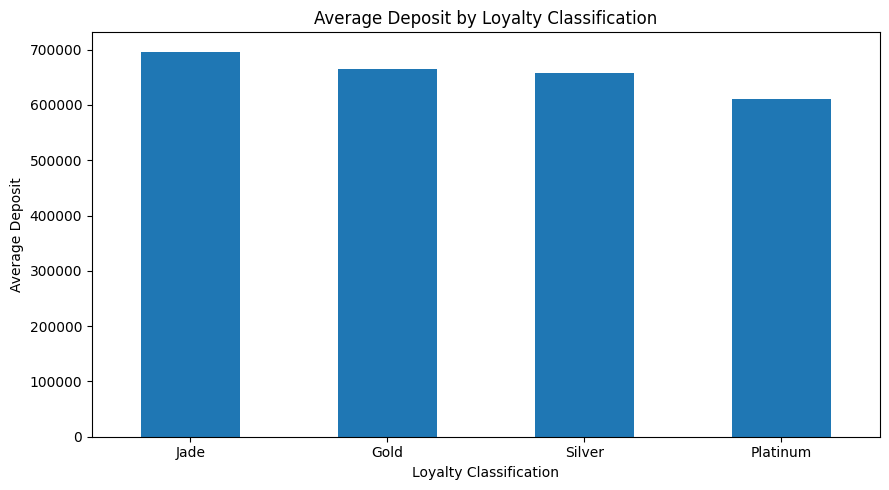

In [49]:
loyalty_summary['Avg_Deposit'].plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Average Deposit by Loyalty Classification')
plt.xlabel('Loyalty Classification')
plt.ylabel('Average Deposit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 7. Key Business Insights

The following outputs summarize the main findings directly from the dataset.


In [50]:
# Automatically surface the main findings used in the executive summary.

highest_income_band = income_summary.loc[
    income_summary['Customers'].idxmax(), 'Income Band'
]

highest_loan_nationality = nationality_loans.index[0]
highest_account_type = account_totals.index[0]
highest_loan_component = loan_components.index[0]
highest_deposit_loyalty = loyalty_summary.index[0]
highest_avg_loan_risk = risk_summary.loc[
    risk_summary['Avg_Loan'].idxmax(), 'Risk Weighting'
]

print(f'1. Largest customer segment by count: {highest_income_band} income band.')
print(f'2. Nationality with highest total bank loans: {highest_loan_nationality}.')
print(f'3. Account type with highest total balance: {highest_account_type}.')
print(f'4. Largest loan portfolio component: {highest_loan_component}.')
print(f'5. Loyalty segment with highest average deposit: {highest_deposit_loyalty}.')
print(f'6. Risk weighting with highest average bank loan: {highest_avg_loan_risk}.')
print(f'7. Income vs bank-loan correlation: {income_loan_corr:.2f}.')
print(f'8. Income vs bank-deposit correlation: {income_deposit_corr:.2f}.')


1. Largest customer segment by count: Mid income band.
2. Nationality with highest total bank loans: European.
3. Account type with highest total balance: Bank Deposits.
4. Largest loan portfolio component: Business Lending.
5. Loyalty segment with highest average deposit: Jade.
6. Risk weighting with highest average bank loan: 5.
7. Income vs bank-loan correlation: 0.33.
8. Income vs bank-deposit correlation: 0.26.


## 8. Business Recommendations

- Compare lending and deposit behavior across income segments to identify financially active customer groups.
- Monitor customer segments with relatively high loan exposure for deeper credit-risk investigation.
- Use loyalty-segment deposit behavior to identify opportunities for customer retention and cross-selling.
- Analyze account-level balances to understand which banking products contribute most to customer deposits.
- Use nationality and occupation analysis to understand concentration of lending activity.
- Treat correlation findings as indicators of association rather than evidence of causation.
